In [8]:
# #makes graphs and other visuals appear directly underneath the code cell
# %matplotlib inline

#importing the other things we need
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

In [10]:
#searching TESS for celestial object named "HAT-P-11" in sector 14
search_result = lk.search_tesscut('HAT-P-11', sector=14)
search_result

# #if for some reason we get a 504 HTTP Gateway Timeout error, do this:
# lk.log.setLevel('INFO')

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 14,2019,TESScut,1426,HAT-P-11,0.0


In [17]:
#downloading the FFI for what we just searched for
    #specifying the size (20 x 20 [pixels]) of the square we want to cut out of our FFI
tpf = search_result.download(cutout_size=20)

In [23]:
#making a target mask to later use as an aperture mask to pull a lightcurve from a bright celestial object
target_mask = tpf.create_threshold_mask(threshold=15, reference_pixel='center')
#summing and printing out how many pixels made it past the threshold we just set, from these pixels we will make a light curve
n_target_pixels = target_mask.sum()
n_target_pixels

np.int64(10)

<Axes: title={'center': 'Target ID: HAT-P-11, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

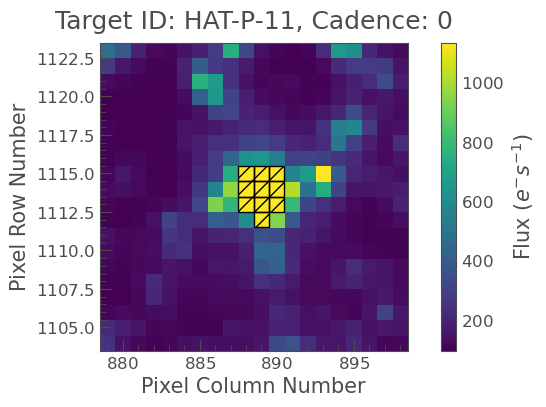

In [24]:
#plotting the 20x20 pixel snapshot, as well as the aperture mask to visually confirm we are looking at and grabbing what we wanted
tpf.plot(aperture_mask=target_mask, mask_color='k')

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

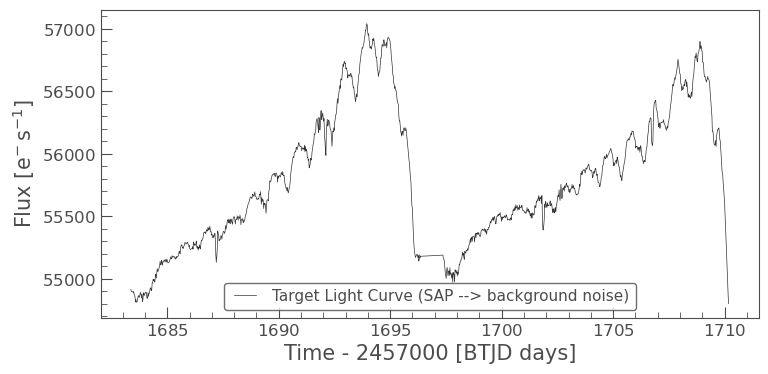

In [25]:
#creating a light curve of what is inside our target aperture mask using Simple Aperture Photometry (SAP)
    #this gives us the raw data, so probably has some noise
target_lc = tpf.to_lightcurve(aperture_mask=target_mask)

#plotting this light curve
target_lc.plot(label='Target Light Curve (SAP --> background noise)')

<Axes: title={'center': 'Target ID: HAT-P-11, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

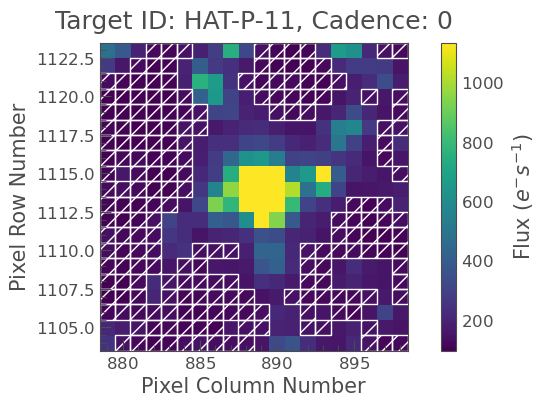

In [26]:
#a clever way of clearing out the background noise is to figure out how much flux are in the "empty" pixels (make another light curve), then use that as a rough reference point by subtracting it from your main light curve data 
    #creating another threshold mask to find the most "empty" pixels
background_mask = ~tpf.create_threshold_mask(threshold=0.001, reference_pixel=None)

#plotting that background_mask for visual confirmation
tpf.plot(aperture_mask=background_mask, mask_color='w')

In [27]:
#summing up and printing how many pixels pass the background threshold
n_background_pixels = background_mask.sum()
n_background_pixels

np.int64(201)

In [28]:
#making a light curve of the average flux per pixel in the background
background_lc_per_pixel = (tpf.to_lightcurve(aperture_mask=background_mask)) / (n_background_pixels)

#using that to make a light curve that estimates the total amount of background flux in the 10 pixels of our celestial object
background_estimate_lc = background_lc_per_pixel * n_target_pixels

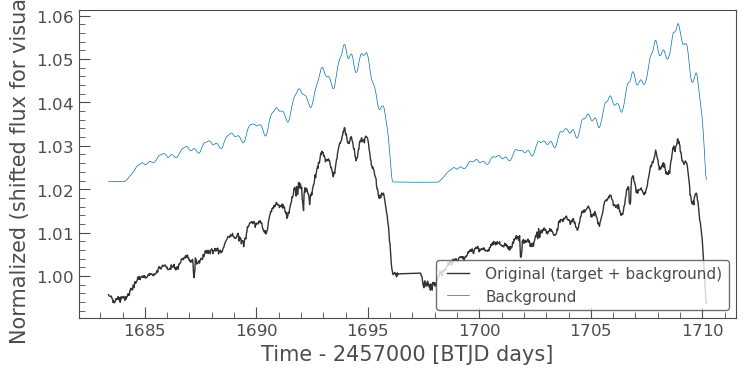

In [35]:
#plotting both the original light curve and the background
common_normalization = np.nanpercentile(target_lc.flux, 10)
ax = (target_lc / common_normalization).plot(normalize=False, label="Original (target + background)", lw=1);
(background_estimate_lc / common_normalization + 1).plot(ax=ax, normalize=False, label="Background", ylabel="Normalized (shifted flux for visual)");

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

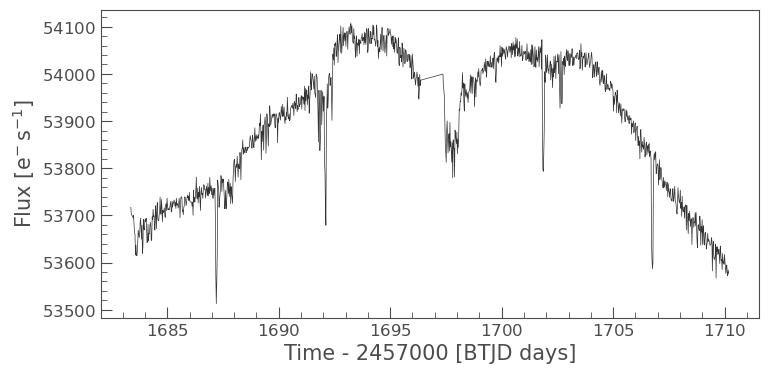

In [37]:
#now subtracting the background from the original to just get the target light curve
corrected_lc = target_lc - background_estimate_lc.flux

#and plotting the final (solid estimate) light curve of HAT-P-11 (i.e., its transit signal showing us flux)
corrected_lc.plot()

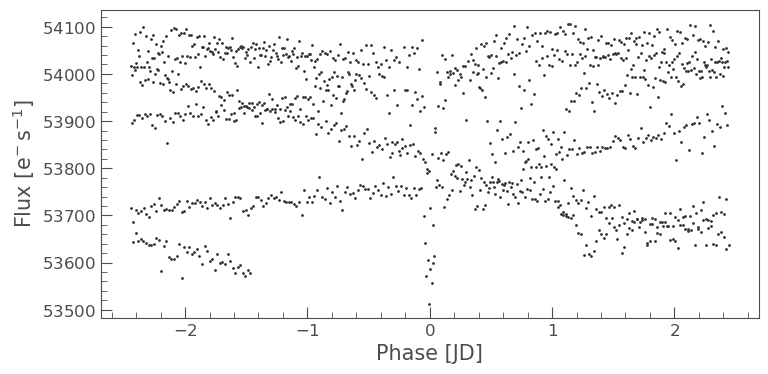

In [43]:
#folding it on its known period of 4.887802443 days
period_days = 4.887802443
epoch_time = 2454605.89132 - 2457000

#and plotting the folded light curve as a scatterplot
ax = corrected_lc.fold(period_days, epoch_time = epoch_time).scatter()

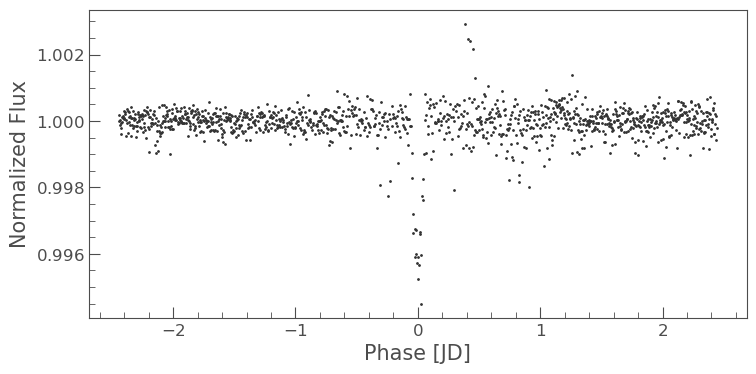

In [45]:
#can do the same but now also flatten the graph...
ax = corrected_lc.flatten(101).fold(period_days, epoch_time=epoch_time).scatter();

In [66]:
#now doing the same thing but with a different celestial object, "L 98-59"
search_result2 = lk.search_tesscut('L 98-59', sector=8)
search_result2

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 08,2019,TESScut,1426,L 98-59,0.0


In [67]:
#downloading what we just searched for and cutting out a 20x20 pixel snapshot of the full frame image (FFI)
tpf2 = search_result2.download(cutout_size=20)

<Axes: title={'center': 'Target ID: L 98-59, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

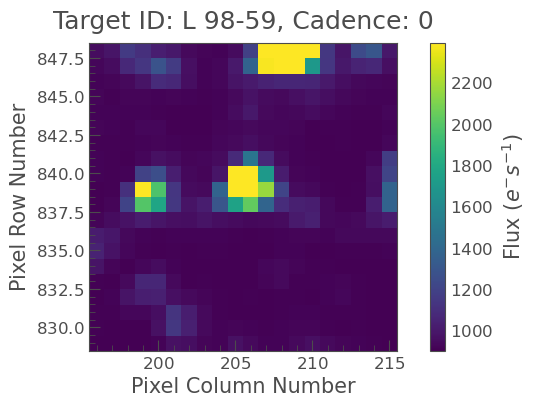

In [68]:
#visually checking out snapshot
tpf2.plot()

<Axes: title={'center': 'Target ID: L 98-59, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

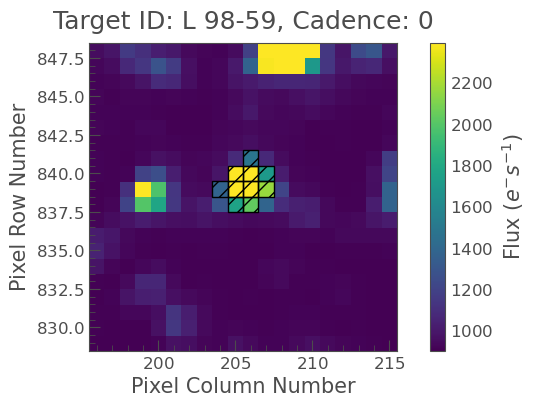

In [70]:
#making a target mask that only our celestial object's flux will make it through
target_mask2 = tpf2.create_threshold_mask(threshold=15, reference_pixel='center')
#summing and printing out how many pixels made it past the threshold we just set, from these pixels we will make a light curve
n_target_pixels2 = target_mask2.sum()
n_target_pixels2
#plotting the same snapshot but now with the mask to show where we are identifying our celestial object
tpf2.plot(aperture_mask=target_mask2, mask_color='k')

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

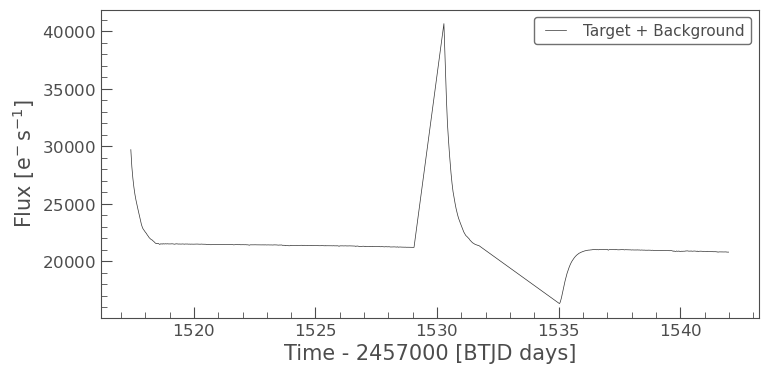

In [71]:
#turning whatever pixels are in the mask into a light curve
target_lc2 = tpf2.to_lightcurve(aperture_mask=target_mask)
#plotting this light curve
target_lc2.plot(label='Target + Background')

<Axes: title={'center': 'Target ID: L 98-59, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

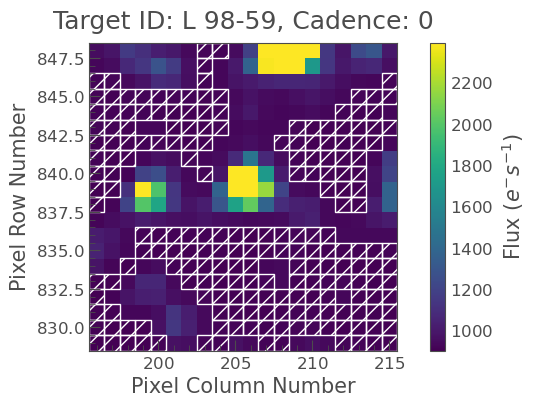

In [72]:
#estimating the background noise
    #first have to mask off the "empty" pixels
background_mask2 = ~tpf2.create_threshold_mask(threshold=0.001, reference_pixel=None)
#plotting that background_mask for visual confirmation
tpf2.plot(aperture_mask=background_mask2, mask_color='w')


In [74]:
#using that mask to create another light curve, which we will ultimately subtract from original light curve to just get target light curve
    #firt summing up and printing how many pixels pass the background threshold (need this later)
n_background_pixels2 = background_mask2.sum()
n_background_pixels2

np.int64(200)

In [76]:
#now making a light curve of the average flux per "empty" pixel
background_lc_per_pixel2 = (tpf2.to_lightcurve(aperture_mask=background_mask2)) / (n_background_pixels2)
#scalar multiplying that light curve by the amount of background pixels to find an estimate of the total amount of background flux (noise)
background_estimate_lc2 = background_lc_per_pixel2 * n_target_pixels2

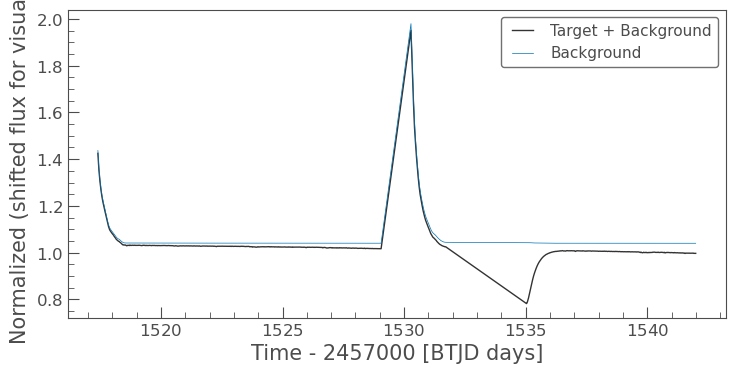

In [78]:
#plotting both the original light curve and the background
common_normalization2 = np.nanpercentile(target_lc2.flux, 10)
ax2 = (target_lc2 / common_normalization2).plot(normalize=False, label="Target + Background", lw=1);
(background_estimate_lc2 / common_normalization2 + 1).plot(ax=ax2, normalize=False, label="Background", ylabel="Normalized (shifted flux for visual)");

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

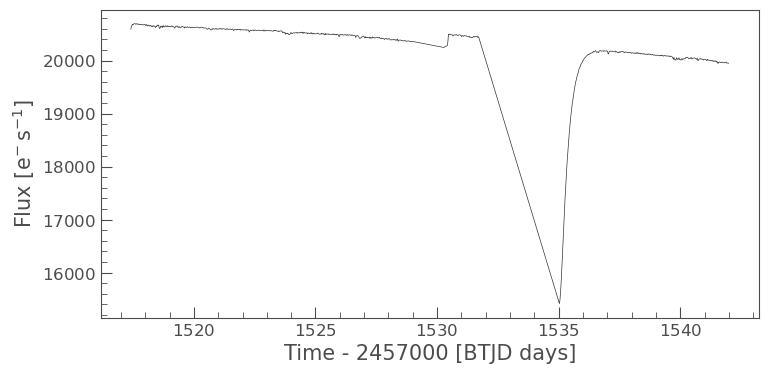

In [79]:
#now subtracting the background from the original to just get the target light curve
corrected_lc2 = target_lc2 - background_estimate_lc2.flux
#plotting it
corrected_lc2.plot()

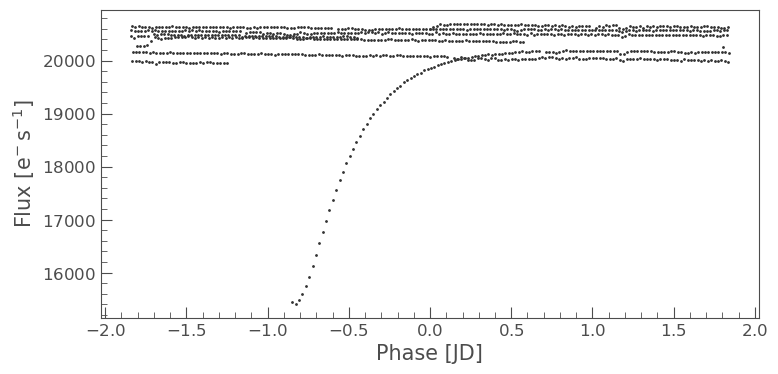

In [81]:
#and a folded scatter plot version...
period = 3.690621 
ax2 = corrected_lc2.fold(period).scatter()

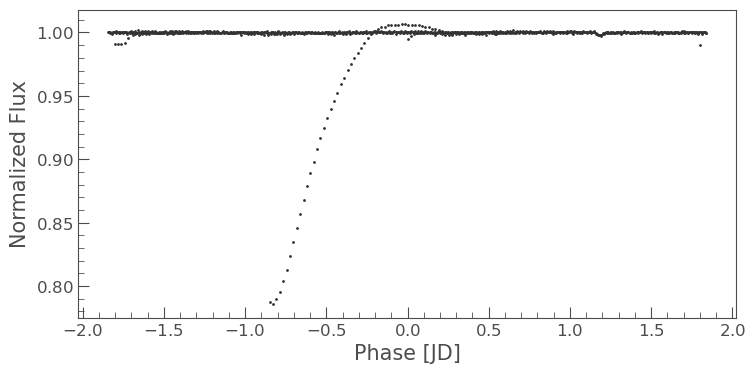

In [82]:
#and a folded + flattened
ax2 = corrected_lc2.flatten(101).fold(period).scatter();